# $y_0$-$M_{500c}$ scaling relation

We investigate the central Compton-$y$ amplitude $y_0$ as a function of halo mass $M_{500c}$ using the derived catalogue `halo_catalogue_M500c_5e13_zlt3_y0q_arnaudB1.csv` (the B=1 Arnaud-GNFW $y_0$, with $y_0 = 1.5639\,Y_{5R500c}/R_{500c}^2$). First a simple look at the data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Publication-quality plot defaults
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})


from flamingo import paths
from flamingo.catalogue import load_catalogue

CAT = paths.HYDRO / 'catalogue' / 'halo_catalogue_M500c_5e13_zlt3_y0q_arnaudB1.csv'
df = load_catalogue(CAT)
df = df[np.isfinite(df['y0']) & (df['y0'] > 0)]
print('clusters:', len(df))
print('columns:', list(df.columns))
print(df[['M_500c_Msun', 'y0', 'z']].describe().round(4).to_string())


clusters: 1555542
columns: ['snap', 'z', 'M_500c_Msun', 'R_500c_Mpc', 'Y_5R500c_Mpc2', 'theta500_arcmin', 'y0', 'sigma_y0', 'q']
        M_500c_Msun            y0             z
count  1.555542e+06  1.555542e+06  1.555542e+06
mean   8.902150e+13  0.000000e+00  8.891000e-01
std    5.834199e+13  0.000000e+00  4.405000e-01
min    5.008000e+13  0.000000e+00  3.200000e-03
25%    5.784000e+13  0.000000e+00  5.610000e-01
50%    7.048000e+13  0.000000e+00  8.274000e-01
75%    9.696000e+13  0.000000e+00  1.153200e+00
max    2.065920e+15  5.000000e-04  2.999400e+00


## Simple plot: $y_0$ vs $M_{500c}$

Log-log density (1.5M clusters), with the running median to show the scaling.

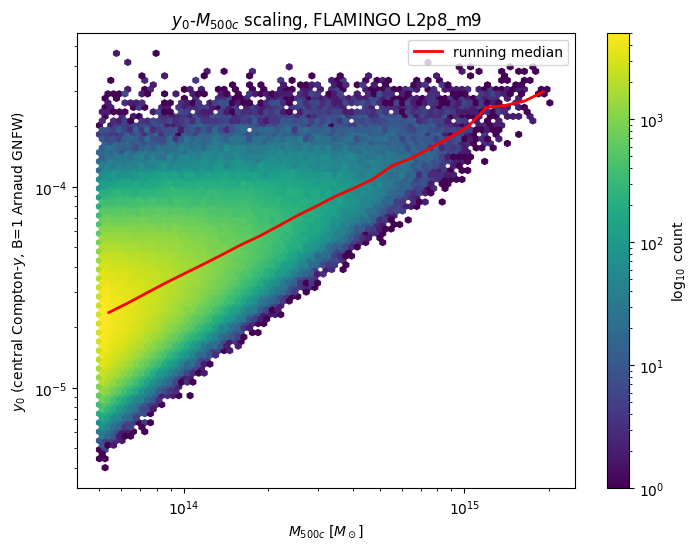

In [2]:
M = df['M_500c_Msun'].values
y0 = df['y0'].values

fig, ax = plt.subplots(figsize=(7.2, 5.6))
hb = ax.hexbin(M, y0, xscale='log', yscale='log', gridsize=80, bins='log', cmap='viridis', mincnt=1)

# running median in log-mass bins
edges = np.logspace(np.log10(M.min()), np.log10(M.max()), 25)
cen = np.sqrt(edges[:-1] * edges[1:])
med = np.array([np.median(y0[(M >= edges[i]) & (M < edges[i+1])]) if np.any((M >= edges[i]) & (M < edges[i+1])) else np.nan
                for i in range(len(cen))])
ax.plot(cen, med, 'r-', lw=2, label='running median')

ax.set_xlabel(r'$M_{500c}\;[M_\odot]$')
ax.set_ylabel(r'$y_0$ (central Compton-$y$, B=1 Arnaud GNFW)')
ax.set_title(r'$y_0$-$M_{500c}$ scaling, FLAMINGO L2p8_m9')
cb = fig.colorbar(hb, ax=ax); cb.set_label(r'$\log_{10}$ count')
ax.legend(fontsize=10)
fig.tight_layout(); plt.show()

## Fit the scaling relation

Power law with redshift evolution, $\log_{10} y_0 = a + \alpha\,(\log_{10} M_{500c} - \log_{10} M_{\rm piv}) + \beta\,\log_{10} E(z)$, with $M_{\rm piv}=3\times10^{14}\,M_\odot$ and $E(z)=H(z)/H_0$ from the D3A cosmology. Self-similar expectation: since $y_0=1.5639\,Y_{5R500c}/R_{500c}^2$ with $Y\propto M^{5/3}E^{2/3}$ and $R_{500c}^2\propto (M/E^2)^{2/3}$, one expects $y_0\propto M^{1}E(z)^{2}$ ($\alpha\simeq1,\ \beta\simeq2$).

log10 y0 = -4.325 + 0.903 (log10 M500 - log10 3e14) + 1.629 log10 E(z)
   -> y0 ~ M^0.90 E(z)^1.63   (self-similar: M^1 E^2)
lognormal scatter = 0.116 dex


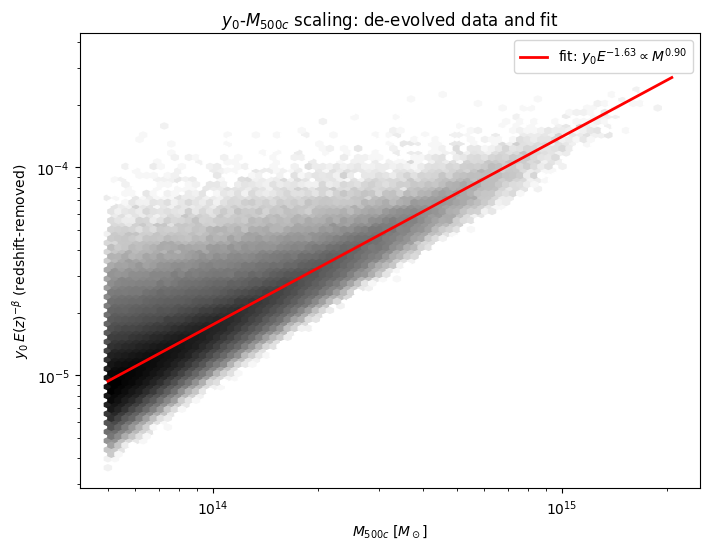

In [3]:
from flamingo.catalogue import frame

z = df['z'].values
lM = np.log10(M)
ly = np.log10(y0)
Ez = frame.efunc(z)                          # E(z) = H(z)/H0, D3A cosmology
logMpiv = np.log10(3e14)

X = np.column_stack([np.ones_like(lM), lM - logMpiv, np.log10(Ez)])
coef, *_ = np.linalg.lstsq(X, ly, rcond=None)
a, alpha, beta = coef
sigma_dex = float(np.std(ly - X @ coef))
print(f'log10 y0 = {a:.3f} + {alpha:.3f} (log10 M500 - log10 3e14) + {beta:.3f} log10 E(z)')
print(f'   -> y0 ~ M^{alpha:.2f} E(z)^{beta:.2f}   (self-similar: M^1 E^2)')
print(f'lognormal scatter = {sigma_dex:.3f} dex')

# de-evolved view: divide out the E(z) dependence so the mass trend is clean
y0_de = y0 / Ez**beta
fig, ax = plt.subplots(figsize=(7.2, 5.6))
ax.hexbin(M, y0_de, xscale='log', yscale='log', gridsize=80, bins='log', cmap='Greys', mincnt=1)
Mline = np.logspace(np.log10(M.min()), np.log10(M.max()), 50)
ax.plot(Mline, 10.0**(a + alpha * (np.log10(Mline) - logMpiv)), 'r-', lw=2,
        label=fr'fit: $y_0 E^{{-{beta:.2f}}} \propto M^{{{alpha:.2f}}}$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$M_{500c}\;[M_\odot]$')
ax.set_ylabel(r'$y_0\,E(z)^{-\beta}$ (redshift-removed)')
ax.set_title(r'$y_0$-$M_{500c}$ scaling: de-evolved data and fit')
ax.legend(fontsize=10)
fig.tight_layout(); plt.show()

## Resolved (detected) clusters in the $y_0$-$M_{500c}$ plane

The undetected background population (grey) versus the SZ-resolved clusters at increasing significance ($q>5,10,20$, reds). Higher-$q$ clusters sit at higher $y_0$ / higher mass, as expected for a noise-limited selection.

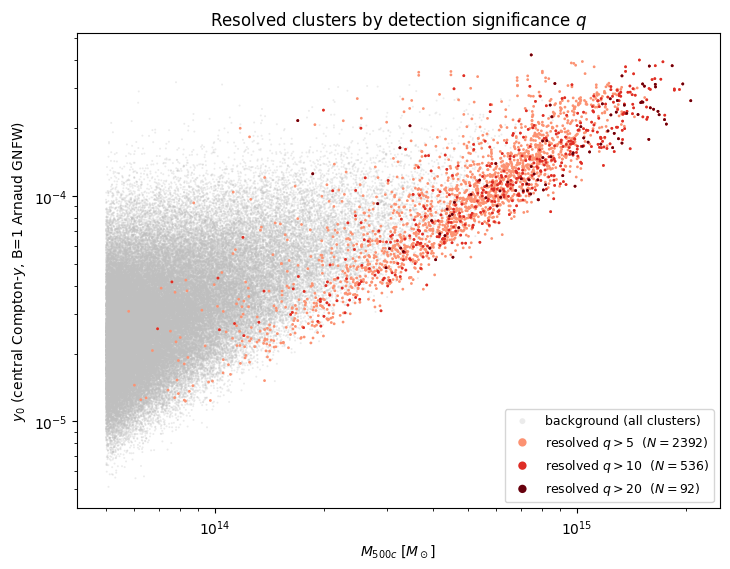

In [4]:
qv = df['q'].values
rng = np.random.default_rng(0)
bg = rng.choice(len(df), size=80000, replace=False)   # subsample the background for plotting

fig, ax = plt.subplots(figsize=(7.4, 5.8))
ax.scatter(M[bg], y0[bg], s=2, c='0.75', alpha=0.3, edgecolors='none',
           rasterized=True, label='background (all clusters)')
for qc, col in [(5, '#fc9272'), (10, '#de2d26'), (20, '#67000d')]:
    sel = qv > qc
    ax.scatter(M[sel], y0[sel], s=4, c=col, edgecolors='none',
               label=fr'resolved $q>{qc}$  ($N={int(sel.sum())}$)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$M_{500c}\;[M_\odot]$')
ax.set_ylabel(r'$y_0$ (central Compton-$y$, B=1 Arnaud GNFW)')
ax.set_title(r'Resolved clusters by detection significance $q$')
ax.legend(fontsize=9, markerscale=3, loc='lower right')
fig.tight_layout(); plt.show()

## Inferring the hydrostatic bias $B$ from $y_0$ (mirror of notebook 13)

This is the $y_0$ analogue of the $Y_{5R500c}$ inference in notebook 13, using the **same A10 convention**: the bias rescales the mass *everywhere*, $M\to M/B$, in both the normalisation $P_{500}(M/B)$ **and** the radius $R_{500c}(M/B)$. The central Compton-$y$ is the line-of-sight integral through the centre,
$$
y_0^{\rm A10}(M,z;B)=\frac{\sigma_T}{m_ec^2}\,P_0\,P_{500}\!\Big(\tfrac{M}{B},z\Big)\,R_{500c}\!\Big(\tfrac{M}{B},z\Big)\,\mathcal{I}_{\rm los},
\qquad \mathcal{I}_{\rm los}=2\!\int_0^5 p(s)\,ds .
$$
Since $P_{500}\propto(M/B)^{2/3+\alpha_p}$ and $R_{500c}\propto(M/B)^{1/3}$, we have $y_0\propto(M/B)^{1+\alpha_p}E(z)^2$, i.e. exponent $\gamma_{y_0}=1+\alpha_p=1.12$ (vs $\gamma_Y=5/3+\alpha_p=1.79$ for the integrated $Y$). Hence
$$
B=\Big[y_0^{\rm A10}(M,z;B{=}1)\big/y_0^{\rm meas}\Big]^{1/\gamma_{y_0}} .
$$

**Consistency with notebook 13.** $y_0$ and $Y_{5R500c}$ carry the same information ($y_0=1.5639\,Y/R_{500c}^2$), but they respond to $B$ *differently*: $Y\propto B^{-1.79}$ while $y_0\propto B^{-1.12}$ (one fewer power of $R_{500c}$, because $y_0$ is a line-of-sight rather than a volume integral). A given amplitude offset therefore maps to $B_{y_0}=B_Y^{\gamma_Y/\gamma_{y_0}}=B_Y^{1.59}$, so the two inferences **coincide only at $B=1$**, and $B_{y_0}$ is steeper in mass. They would be made identical *only* by holding $R_{500c}$ fixed at the measured value instead of rescaling it, which is the non-self-consistent choice we avoid here.

In [5]:
from scipy.integrate import quad
from flamingo.catalogue import frame, D3A_COSMOLOGY

h = D3A_COSMOLOGY.H0 / 100.0
RHO_C0 = 2.775e11 * h * h                          # Msun/Mpc^3 proper, z=0
ALPHA_P = 0.12
GAMMA_Y, GAMMA_Y0 = 5/3 + ALPHA_P, 1 + ALPHA_P     # 1.7867, 1.12

# GNFW shape (hmfast A10 defaults; same shape that fixed the catalogue K=1.5639).
P0g, c500, al, be, ga = 8.130, 1.156, 1.0620, 5.4807, 0.3292
def pg(x):
    cx = c500 * np.maximum(x, 1e-12); return cx**(-ga) * (1 + cx**al)**((ga - be) / al)
I5   = quad(lambda x: pg(x) * x * x, 0, 5, limit=400)[0]   # volume (Y) shape integral
Ilos = 2 * quad(lambda s: pg(s),     0, 5, limit=400)[0]   # central (y0) LOS shape integral
print(f'shape check: K = Ilos/(4 pi I5) = {Ilos/(4*np.pi*I5):.4f}  (catalogue used 1.5639)')

ST, MEC2, MPC = 6.6524587e-25, 510998.95, 3.0856775814913673e24
Ymeas = df['Y_5R500c_Mpc2'].values                 # = D_A^2 Y_sph, proper Mpc^2

def R500_of_M(Mm, zz):                             # proper R_500c [Mpc]; pass M/B for the bias
    return (3 * Mm / (4 * np.pi * 500 * RHO_C0 * frame.efunc(zz)**2))**(1/3)

# sanity: catalogue R500 must be reproduced from M (proper-radius / rho_c convention)
print(f'R500 cat / R500(M): median = {np.median(df["R_500c_Mpc"].values / R500_of_M(M, z)):.5f}')

def P500_eVcm3(Mm, zz, B):
    return (1.65 * (h/0.7)**2 * frame.efunc(zz)**(8/3)
            * ((Mm / B) * h / (0.7 * 3e14))**(2/3 + ALPHA_P) * (0.7/h)**1.5)

def y0_A10(Mm, zz, B):                             # central Compton-y, dimensionless
    Rcm = R500_of_M(Mm / B, zz) * MPC
    return (ST/MEC2) * P0g * P500_eVcm3(Mm, zz, B) * Rcm * Ilos

def Y_A10(Mm, zz, B):                              # integrated Y [Mpc^2], matches nb13
    Rcm = R500_of_M(Mm / B, zz) * MPC
    return (ST/MEC2) * 4*np.pi * P0g * P500_eVcm3(Mm, zz, B) * Rcm**3 * I5 / MPC**2

B_y0 = (y0_A10(M, z, 1.0) / y0)**(1/GAMMA_Y0)      # full rescaling, gamma_y0 = 1.12
B_Y  = (Y_A10(M, z, 1.0) / Ymeas)**(1/GAMMA_Y)     # nb13 inference, gamma_Y = 1.79

print(f'median y0_meas / y0_A10(B=1) = {np.median(y0 / y0_A10(M, z, 1.0)):.4f}')
print('               median   M>1e14   M>2e14   M>5e14')
for lbl, B in [('B from y0 ', B_y0), ('B from Y  ', B_Y)]:
    print(f'  {lbl}  {np.median(B):.3f}    {np.median(B[M>1e14]):.3f}    '
          f'{np.median(B[M>2e14]):.3f}    {np.median(B[M>5e14]):.3f}')
print(f'  cross-check B_y0 = B_Y^(gamma_Y/gamma_y0): '
      f'{np.median(B_y0):.3f} vs {np.median(B_Y)**(GAMMA_Y/GAMMA_Y0):.3f}')

shape check: K = Ilos/(4 pi I5) = 1.5639  (catalogue used 1.5639)
R500 cat / R500(M): median = 0.99983


median y0_meas / y0_A10(B=1) = 0.9837
               median   M>1e14   M>2e14   M>5e14
  B from y0   1.015    1.112    1.229    1.426
  B from Y    1.009    1.069    1.139    1.249
  cross-check B_y0 = B_Y^(gamma_Y/gamma_y0): 1.015 vs 1.015


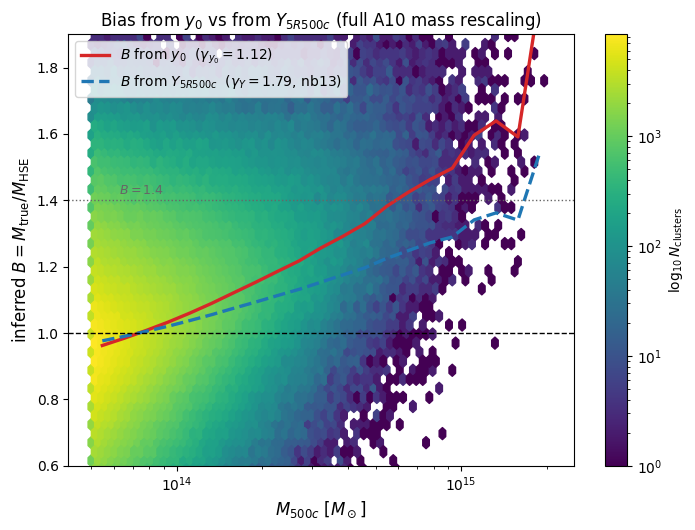

In [6]:
# B-vs-mass figure (the nb13 plot, but inferred from y0), with the Y-based curve overlaid.
fig, ax = plt.subplots(figsize=(7.2, 5.4))
hb = ax.hexbin(M, B_y0, xscale='log', gridsize=70, bins='log', cmap='viridis', mincnt=1)
cb = fig.colorbar(hb, ax=ax); cb.set_label(r'$\log_{10} N_{\rm clusters}$')

edges = np.logspace(np.log10(M.min()), np.log10(M.max()), 22)
cen = np.sqrt(edges[:-1] * edges[1:])
def runmed(B):
    return np.array([np.median(B[(M >= edges[i]) & (M < edges[i+1])])
                     if np.any((M >= edges[i]) & (M < edges[i+1])) else np.nan
                     for i in range(len(cen))])
ax.plot(cen, runmed(B_y0), color='#d62728', lw=2.4, label=r'$B$ from $y_0$  ($\gamma_{y_0}=1.12$)')
ax.plot(cen, runmed(B_Y),  color='#1f77b4', lw=2.4, ls='--',
        label=r'$B$ from $Y_{5R500c}$  ($\gamma_Y=1.79$, nb13)')
ax.axhline(1.0, color='k', ls='--', lw=1.0)
ax.axhline(1.4, color='0.4', ls=':', lw=1.0)
ax.text(M.min() * 1.25, 1.42, r'$B=1.4$', fontsize=9, color='0.4')

ax.set_xlabel(r'$M_{500c}\ [M_\odot]$', fontsize=12)
ax.set_ylabel(r'inferred $B = M_{\rm true}/M_{\rm HSE}$', fontsize=12)
ax.set_ylim(0.6, 1.9)
ax.set_title(r'Bias from $y_0$ vs from $Y_{5R500c}$ (full A10 mass rescaling)', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.tick_params(labelsize=10)
fig.tight_layout()
fig.savefig('../autoresearch/figures/nb12_B_from_y0.pdf')
fig.savefig('../autoresearch/figures/nb12_B_from_y0.png', dpi=300)
plt.show()